In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
try:
  # This command only in Colab.
  %tensorflow_version 2.x
except Exception:
  pass
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, Flatten, Dropout, MaxPooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import os
import numpy as np
import matplotlib.pyplot as plt
# # Get project files
# !wget https://cdn.freecodecamp.org/project-data/cats-and-dogs/cats_and_dogs.zip

# !unzip cats_and_dogs.zip

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
PATH = 'data_small/cats_and_dogs'

# Get number of files in each directory. The train and validation directories
# each have the subdirecories "dogs" and "cats".
train_dir      = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')
test_dir       = os.path.join(PATH, 'test')

# -1 because of DS_Store
total_train = sum([len(files) for r, d, files in os.walk(train_dir)])#-1
total_val   = sum([len(files) for r, d, files in os.walk(validation_dir)])#-1
total_test  = len(os.listdir(test_dir))#-1

print('Train:', total_train) 
print('Validation:', total_val)
print('Test:', total_test)
# Variables for pre-processing and training.
batch_size = 128
epochs = 30
IMG_HEIGHT = 150
IMG_WIDTH = 150

Train: 200
Validation: 60
Test: 50


In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# 3

train_image_generator = ImageDataGenerator(rescale = 1./255)
validation_image_generator = ImageDataGenerator(rescale = 1./255)
test_image_generator = ImageDataGenerator(rescale = 1./255)

train_data_gen = train_image_generator.flow_from_directory(
    directory =train_dir,
    batch_size = batch_size,
    class_mode = "binary",
    target_size=(IMG_HEIGHT,IMG_WIDTH)
)
val_data_gen = validation_image_generator.flow_from_directory(
    directory = validation_dir,
    batch_size = batch_size,
    class_mode = "binary",
    target_size=(IMG_HEIGHT,IMG_WIDTH)
)
test_data_gen  = test_image_generator.flow_from_directory(
                    PATH,
                    target_size=(IMG_HEIGHT, IMG_WIDTH),
                    batch_size=batch_size,
                    classes=['test'],
                    shuffle=False)
#We took The path and chose the name of the test as a class, so that we can extract them

Found 200 images belonging to 2 classes.
Found 60 images belonging to 2 classes.
Found 50 images belonging to 1 classes.


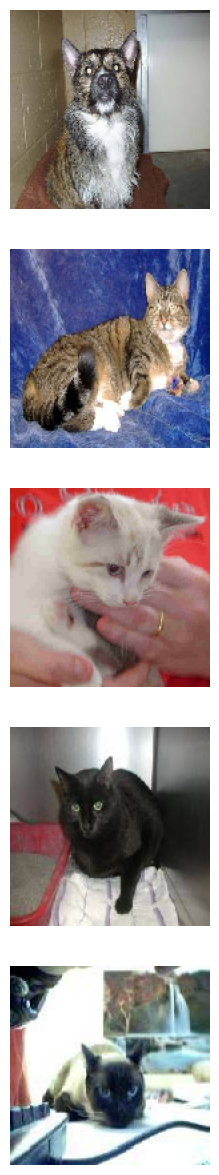

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
# 4
def plotImages(images_arr, probabilities = False):
    fig, axes = plt.subplots(len(images_arr), 1, figsize=(5,len(images_arr) * 3))
    if probabilities is False:
      for img, ax in zip( images_arr, axes):
          ax.imshow(img)
          ax.axis('off')
    else:
      for img, probability, ax in zip( images_arr, probabilities, axes):
          ax.imshow(img)
          ax.axis('off')
          if probability > 0.5:
              ax.set_title("%.2f" % (probability*100) + "% dog")
          else:
              ax.set_title("%.2f" % ((1-probability)*100) + "% cat")
    plt.show()

sample_training_images, _ = next(train_data_gen)
plotImages(sample_training_images[:5])

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
# 5
train_image_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30, # Increase rotation range
    width_shift_range=0.2, # Increase width shift range
    height_shift_range=0.2, # Increase height shift range
    zoom_range=0.1, # Decrease zoom range
    horizontal_flip=False, # Flip vertically instead of horizontally
    vertical_flip=True, 
    shear_range=0.2, # Add shear augmentation
    channel_shift_range=0.2, # Add channel shift augmentation
)

Found 200 images belonging to 2 classes.


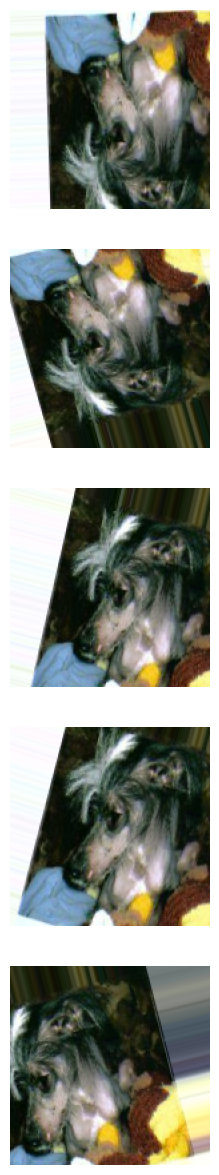

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
# 6
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,
                                                     directory=train_dir,
                                                     target_size=(IMG_HEIGHT, IMG_WIDTH),
                                                     class_mode='binary')

augmented_images = [train_data_gen[0][0][0] for i in range(5)]

plotImages(augmented_images)

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
# 7
from tensorflow.keras.optimizers import Adam
model = Sequential()
from tensorflow.keras import datasets, layers, models, Input
model.add(Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)))
model.add(layers.Conv2D(16, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(16, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(16, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()
optimizer = Adam(0.0005)
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 34, 34, 16)          │           2,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 17, 17, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 4624)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       2,368,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,373,601 (9.05 MB)

 Trainable params: 2,373,601 (9.05 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# 8
history = model.fit(
    train_data_gen,
    validation_data=val_data_gen,
    epochs= 2 #30
)

Epoch 1/2


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 577ms/step - accuracy: 0.4807 - loss: 0.7229 - val_accuracy: 0.5667 - val_loss: 0.6910
Epoch 2/2
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 409ms/step - accuracy: 0.5193 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.7051


In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
model.save("train.h5")

In [10]:
# --- [CELL 9]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
# === BEFORE (original) ===
# model.load ("train.h5")

# === AFTER (edited) ===
from tensorflow.keras.models import load_model
model = load_model("train.h5")

In [11]:
import os
from tensorflow.keras import Model

assert os.path.exists("train.h5"), "Expected saved model file train.h5 to exist before loading."
assert isinstance(model, Model), "model should be a Keras Model instance returned by load_model."
assert hasattr(model, "predict"), "Loaded model should expose predict()."
assert model.count_params() > 0, "Loaded model should have trainable/non-trainable parameters."

# Validate model has learned something
predictions = model.predict(next(val_data_gen)[0])
assert predictions.shape[0] > 0, "Model should produce predictions"
assert np.all(np.isfinite(predictions)), "Predictions should be valid numbers"

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
